# Evaluating Machine Learning Models

Before we talk about how to measure model performance, we need to remember that **a model's performance on its training data tells you almost nothing useful.** A model that simply memorizes all of its training examples can score perfectly on the training data and still fail completely on real-world data. Every evaluation technique in this lecture exists to guard against this. The central question is always: *how well does the model generalize to data it has never seen?*

We've already seen that train/test splits exist to catch overfitting. Now we'll learn more systematic tools for diagnosing model problems and measuring performance.

## The Bias-Variance Tradeoff

We've seen that models can **overfit** as well as **underfit** the training data.
- **Overfitting**: the model performs well on training data but poorly on new data.
- **Underfitting**: the model is so simple it doesn't even capture the training data well.

These are not just opposite extremes. They represent two distinct *sources of prediction error*:

- **Bias**: Error from overly simplistic assumptions. A high-bias model misses the true pattern regardless of how much training data you give it: it is structurally unable to represent the true relationship.

- **Variance**: Error from sensitivity to the specific training set used. A high-variance model learns the noise along with the signal, so its predictions vary wildly if you swap in a different training set.

| Model type | Bias | Variance |
|---|---|---|
| Too simple (e.g., linear model on non-linear data) | High | Low |
| Too complex (e.g., degree-20 polynomial, huge neural net) | Low | High |
| Just right | Low | Low |

**The bias-variance tradeoff is the fundamental reason we need careful model selection and separate data for evaluation.** It's very easy to make a model that is too simple or too complex, but it's much harder to get it right in the sweet spot.

### Intuition: The Dartboard Analogy

Imagine throwing darts at a dartboard, and repeating the experiment many times, each time re-training your model on a fresh random sample of training data. The **bullseye** represents the correct prediction. Where the darts land represents your model's predictions.

| Scenario | What it means |
|---|---|
| **Low bias, low variance** | Darts cluster tightly around the bullseye. *This is the ideal outcome.* |
| **High bias, low variance** | Darts cluster tightly, but consistently in the *wrong spot*: a confidently wrong prediction. This is **underfitting**. |
| **Low bias, high variance** | Darts are spread all over, but centered on the bullseye on average. Results are unpredictable run-to-run. This is **overfitting**. |
| **High bias, high variance** | Darts are scattered *and* off-target. Worst of both worlds. |

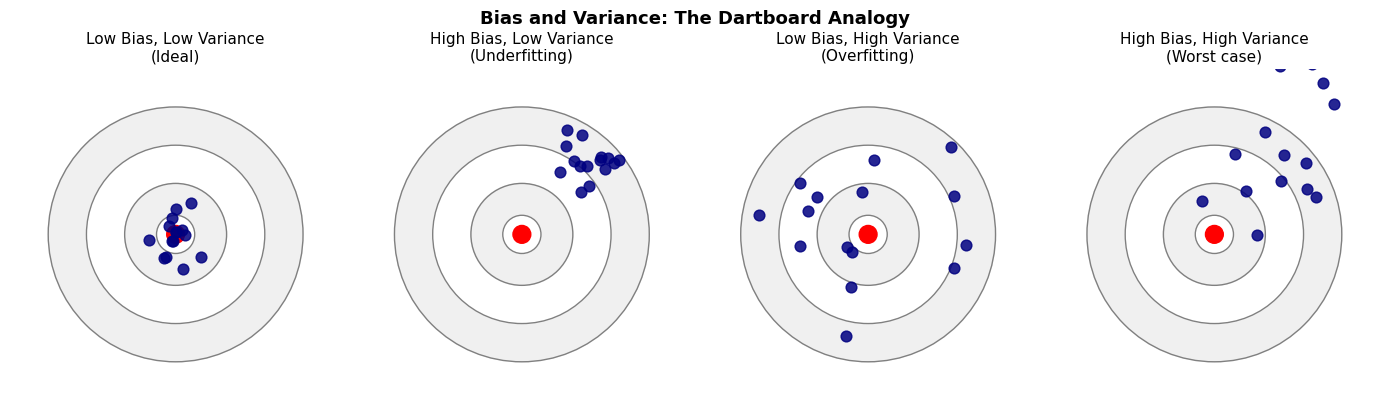

In [82]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

configs = [
    {'title': 'Low Bias, Low Variance\n(Ideal)',          'cx': 0.0,  'cy': 0.0,  'spread': 0.12},
    {'title': 'High Bias, Low Variance\n(Underfitting)',  'cx': 0.55, 'cy': 0.55, 'spread': 0.12},
    {'title': 'Low Bias, High Variance\n(Overfitting)',   'cx': 0.0,  'cy': 0.0,  'spread': 0.45},
    {'title': 'High Bias, High Variance\n(Worst case)',   'cx': 0.55, 'cy': 0.55, 'spread': 0.45},
]

np.random.seed(7)
for ax, cfg in zip(axes, configs):
    for r, c in zip([1.0, 0.7, 0.4, 0.15], ['#f0f0f0', 'white', '#f0f0f0', 'white']):
        ax.add_patch(plt.Circle((0, 0), r, color=c, zorder=1))
        ax.add_patch(plt.Circle((0, 0), r, fill=False, color='gray', lw=1, zorder=2))
    ax.add_patch(plt.Circle((0, 0), 0.07, color='red', zorder=3))
    xs = np.random.normal(cfg['cx'], cfg['spread'], 15)
    ys = np.random.normal(cfg['cy'], cfg['spread'], 15)
    ax.scatter(xs, ys, color='navy', s=60, zorder=4, alpha=0.85)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(cfg['title'], fontsize=11)

plt.suptitle('Bias and Variance: The Dartboard Analogy', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Concrete Example: Polynomial Regression

Suppose the **true** relationship in our data is a parabola (degree-2 polynomial), but we only observe noisy measurements. We'll try fitting polynomials of different degrees to see what happens.  (Remember, we can do this
using our regular linear regression algorithm but by using feature engineering to include the square of our
features, the cube, etc.)

- **Degree 1 (linear)**: A straight line can't fit a curve. The model is structurally incapable of representing the true relationship. It will converge to the best-possible linear approximation of the parabola, which is still systematically wrong everywhere. Adding more training data doesn't help; it only sharpens that wrong answer. This is **high bias**.
- **Degree 3**: Captures the shape without fitting the noise: **low bias, low variance**. 
- **Degree 12**: Squiggles through every training point, so training MSE is nearly zero. But it predicts terribly on new data: **high variance**.

**Critical observation**: Training error keeps *decreasing* as we add complexity, even when the model is getting worse at generalizing. This is exactly why we need a test set: **training error alone cannot detect overfitting**.

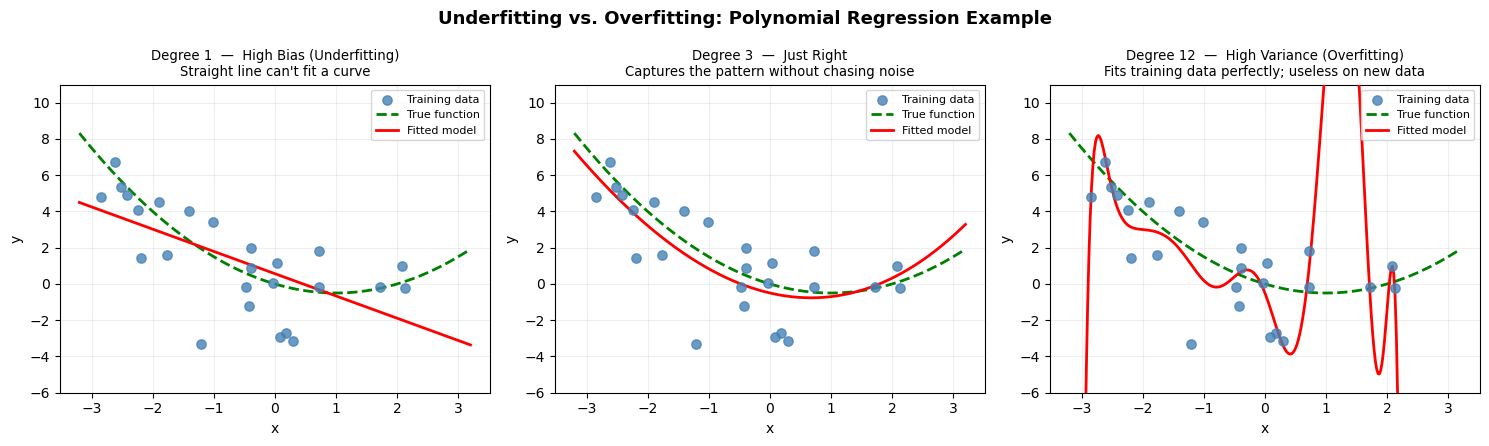

In [83]:
np.random.seed(2)
x_tr = np.sort(np.random.uniform(-3, 3, 25))
y_tr = 0.5 * x_tr**2 - x_tr + np.random.randn(25) * 1.5
x_pl = np.linspace(-3.2, 3.2, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
degrees   = [1, 3, 12]
subtitles = [
    "Degree 1  —  High Bias (Underfitting)\nStraight line can't fit a curve",
    'Degree 3  —  Just Right\nCaptures the pattern without chasing noise',
    'Degree 12  —  High Variance (Overfitting)\nFits training data perfectly; useless on new data',
]

for ax, deg, subtitle in zip(axes, degrees, subtitles):
    p    = np.poly1d(np.polyfit(x_tr, y_tr, deg))
    tmse = np.mean((p(x_tr) - y_tr)**2)
    ax.scatter(x_tr, y_tr, color='steelblue', s=45, alpha=0.8, zorder=4, label='Training data')
    ax.plot(x_pl, 0.5*x_pl**2-x_pl, 'g--', lw=2, label='True function', zorder=3)
    ax.plot(x_pl, p(x_pl), 'r-',  lw=2, label='Fitted model',  zorder=3)
    ax.set_ylim(-6, 11)
    ax.set_title(f'{subtitle}', fontsize=9.5)
    ax.legend(fontsize=8)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.2)

plt.suptitle('Underfitting vs. Overfitting: Polynomial Regression Example', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The polynomial regression example above showed three specific models. But what happens if we systematically sweep through *every* degree from 1 to 13? The plot below shows the classic **bias-variance tradeoff curve**: training error decreases monotonically as we add complexity, but test error has a U-shape — it drops initially, hits a sweet spot, and then climbs as the model begins overfitting.

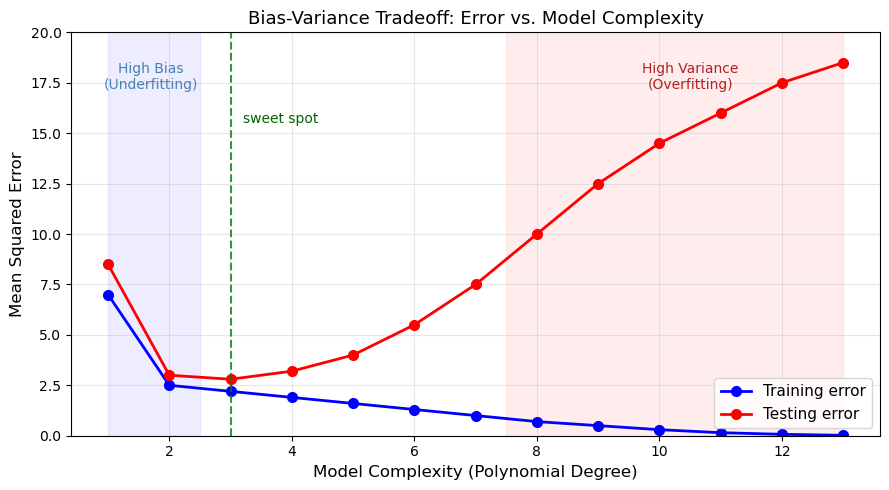

In [84]:
# Complexity increases left to right (polynomial degree 1 through 13)
degrees      = [1,    2,    3,    4,    5,    6,    7,    8,    9,    10,   11,   12,   13  ]
train_errors = [7.0,  2.5,  2.2,  1.9,  1.6,  1.3,  1.0,  0.7,  0.5,  0.30, 0.15, 0.07, 0.02]
test_errors  = [8.5,  3.0,  2.8,  3.2,  4.0,  5.5,  7.5, 10.0, 12.5, 14.5, 16.0, 17.5, 18.5]
#                                  ^
#                            sweet spot (degree 3 ≈ true function)

plt.figure(figsize=(9, 5))
plt.plot(degrees, train_errors, 'b-o', label='Training error', markersize=7, lw=2)
plt.plot(degrees, test_errors,  'r-o', label='Testing error', markersize=7, lw=2)

# Shade underfitting and overfitting regions
plt.axvspan(1,   2.5, alpha=0.07, color='blue')
plt.axvspan(7.5, 13,  alpha=0.07, color='red')

# Mark the sweet spot
plt.axvline(x=3, color='green', linestyle='--', lw=1.5, alpha=0.8)
plt.text(3.2, 15.5, 'sweet spot', fontsize=10, color='darkgreen')

plt.text(1.7,  17.2, 'High Bias\n(Underfitting)', fontsize=10, color='steelblue',  ha='center')
plt.text(10.5, 17.2, 'High Variance\n(Overfitting)', fontsize=10, color='firebrick', ha='center')

plt.ylim(0, 20)
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Bias-Variance Tradeoff: Error vs. Model Complexity', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Train/Test/Validation Splits

In supervised machine learning, we typically have a large collection of labeled data, but we never want to train on *all* of it. We need to hold some back to test whether our model actually generalizes. Training and testing on the same data gives a **biased, optimistic** estimate of real-world performance.

We split our data into sets with distinct roles:

| Set | Purpose |
|---|---|
| **Training set** | Fit the **parameters** of the model (weights, biases) |
| **Validation set** | Tune the **hyperparameters** of the model |
| **Test set** | Final held-out evaluation, to be used once, at the very end |

## Parameters vs. Hyperparameters

**Parameters** are values the model learns automatically during training via gradient descent: the weights and biases in linear regression, logistic regression, and neural networks.

**Hyperparameters** are values *you* set before training begins; gradient descent does not update them. Examples:
- Number of layers or neurons in a neural network
- Polynomial degree in polynomial regression
- Learning rate $\alpha$
- Which features to include in the model

## Why We Need a Validation Set

Here's the problem. Suppose you're building a classifier but you're unsure which features to use. You try several feature combinations and want to pick the best one. **If you evaluate each combination on the test set and pick the best performer, you've used the test set to make a modeling decision** — which is exactly what we're trying to avoid. Your final model was chosen *based on* test performance, so you no longer have a clean measure of how it will behave on truly unseen data.

The solution is the **validation set**: a third slice of data used to compare models and tune hyperparameters, keeping the test set completely untouched until the very end.

**The workflow:**
1. Train each candidate model on the **training set**
2. Evaluate each candidate on the **validation set**, pick the best performer
3. Evaluate the winner on the **test set**, exactly once, then stop

**Once you look at test set performance, you must stop.** Going back to adjust anything based on test results, even informally, is **data leakage.**

## Sizes of These Sets

Split sizes depend on how much data you have:

- **A reasonable default**: **70/15/15** or **80/10/10** (train/val/test)
- **Very large datasets**: Validation and test sets just need to be large enough for reliable estimates. 1–5% each may be sufficient if that's millions of examples
- **Not enough data for meaningful fixed splits**: Use **cross-validation** instead (described below)

The core tension: more training data generally means a better model, but larger test/validation sets give more reliable evaluation estimates.

## Data Leakage

**Data leakage** occurs when information from outside the training set influences the model, either during training or when making modeling decisions. It produces models that look great in evaluation but fail in production. It is one of the most common mistakes in real-world machine learning.

**The general principle: any modeling decision shaped by the test set, directly or indirectly, contaminates it.**

The obvious case is picking the model with the best test accuracy from among several candidates. The subtle cases are where students and professionals actually get caught.
One example (that I've shown you in class) is re-running the ML workflow with different random initializations until we get a "nice-looking" learning curve.  In this case, we
used the performance on the test set (a bad-looking curve) to tell us to re-run the experiment.


### Learning curves with training and validation data

The learning curves we've seen so far usually had just one curve, illustrating how training loss/cost $J(w)$ decreases as the model trains.  
You can also interpret these curves as illustrating the bias-variance tradeoff, especially if you plot both training and validation scores at the same time (very common
in practice).

The three panels below show what each scenario looks like when you watch loss over epochs:

- **High bias**: both training and validation loss decrease quickly but flatten out at a high value. No matter how long you train, the loss won't get much lower — the model simply can't fit the data well. Training longer is wasted effort.
- **Just right**: both losses fall together to a low value and stay there, with only a small gap between them.
- **High variance**: training loss keeps falling toward zero (the model is memorizing), but validation loss reaches a minimum and then *climbs back up*. This is the clearest overfitting signal you will see in practice, and it points directly to a practical remedy: **early stopping** — halt training at the point where validation loss is lowest.

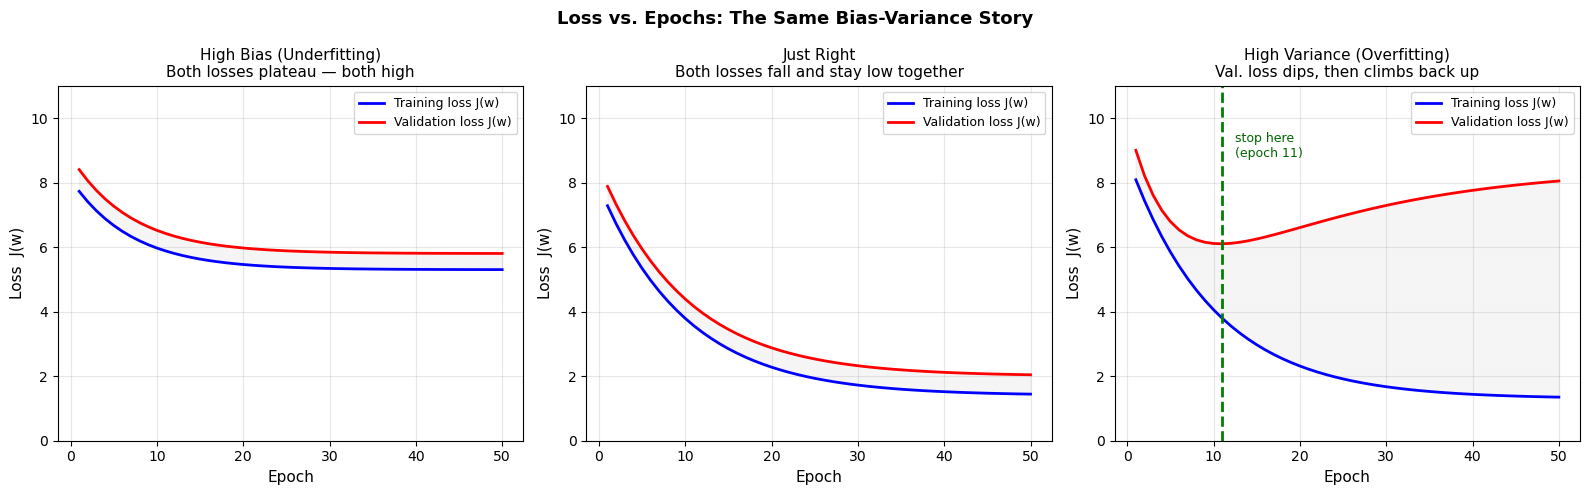

In [85]:
epochs = np.arange(1, 51)

# High bias: both losses plateau at a high value
train_bias = 5.3 + 2.8 * np.exp(-epochs / 7)
val_bias   = 5.8 + 3.0 * np.exp(-epochs / 7)

# Just right: both losses fall to a low value with a small gap
train_good = 1.4 + 6.5 * np.exp(-epochs / 10)
val_good   = 2.0 + 6.5 * np.exp(-epochs / 10)

# High variance: training loss keeps falling, validation loss dips then rises
train_var = 0.3 + 7.5 * np.exp(-epochs / 10)+1
val_var   = 1.0 + 7.0 * np.exp(-epochs / 5) + 5.5 * (1 - np.exp(-epochs / 20))+2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plots = [
    (train_bias, val_bias, 'High Bias (Underfitting)\nBoth losses plateau — both high'),
    (train_good, val_good, 'Just Right\nBoth losses fall and stay low together'),
    (train_var,  val_var,  'High Variance (Overfitting)\nVal. loss dips, then climbs back up'),
]

for ax, (tr, vl, title) in zip(axes, plots):
    ax.plot(epochs, tr, 'b-', label='Training loss J(w)',   lw=2)
    ax.plot(epochs, vl, 'r-', label='Validation loss J(w)', lw=2)
    ax.fill_between(epochs, tr, vl, alpha=0.08, color='gray')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss  J(w)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Mark the optimal early stopping point on the overfitting plot
best_epoch = int(np.argmin(val_var)) + 1
axes[2].axvline(x=best_epoch, color='green', linestyle='--', lw=2)
axes[2].text(best_epoch + 1.5, 8.8, f'stop here\n(epoch {best_epoch})', fontsize=9, color='darkgreen')

plt.suptitle('Loss vs. Epochs: The Same Bias-Variance Story', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways

- **Bias** = systematic error from a model that's too simple. It misses the true pattern regardless of how much data you give it.
- **Variance** = error from a model that's too sensitive to its training data. It memorizes noise instead of learning signal.
- **Simple models**: high bias, low variance. **Complex models**: low bias, high variance.
- The **bias-variance tradeoff** is the fundamental reason we need train/test splits and cross-validation.
- **More data** helps with high variance (overfitting) but does *not* help with high bias (underfitting).
- **Learning curves** are a practical diagnostic: a large gap between training and validation error = variance problem; both errors high with no gap = bias problem.

## Evaluation metrics

- There are various numerical ways to measure the performance of our machine learning models.

- These generally correspond to our cost functions, $J(w)$, for whatever model we are using, though not all evaluation metrics are derived from cost functions.

### Regression metrics

- For regression problems (predicting a number), we can use **mean squared error** (which we use to train
linear regression):

$$\text{MSE} = \frac{1}{m} \sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})^2$$

but this is not the only metric we can use.

- Another common metric is the **mean absolute error**:

$$\text{MAE} = \frac{1}{m} \sum_{i=1}^m \left\vert \hat{y}^{(i)} - y^{(i)} \right\vert$$

One advantage MAE has is the quantity is more "interpretable" in that it has the same units as the target
value $y$.  For example, if we are predicting housing prices in dollars, then the MAE tells us, on average, how
far away our predictions are from the "true" price of a house.  On the other hand, MSE gives us a value 
in "square dollars" which is harder to interpret.

- We can also take the square root of the mean squared error to get the **root-mean-square error**:

$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{ \frac{1}{m} \sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})^2 }$$

RMSE also has the same units as $y$, like MAE. The difference is that RMSE penalizes large errors more heavily (because of the squaring inside), while MAE treats all errors equally. RMSE is the most widely used regression metric in practice.

<hr>

For all of these metrics, lower numbers indicate better predictions.

- $R^2$ (coefficient of determination): This one is a bit different, in that higher values are better, but you might be more familiar with
  this one, and many other people (non-ML people) know it as well.

If ${\displaystyle {\bar {y}}}$ is the mean of the observed data, then we define:

$SS_{res}$ (residual sum of squares) $= \displaystyle \sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})^2$

$SS_{tot}$ (total sum of squares) $= \displaystyle \sum_{i=1}^m (\bar{y} - y^{(i)})^2$

And then, $R^2 = \displaystyle 1 - \frac{SS_{res}}{SS_{tot}}$


In the best case, the predicted values exactly match the observed values, which results in 
${\displaystyle SS_{\text{res}}=0}$ and $R^2 = 1$. A baseline model, which always predicts $\bar{y}$, will have $R^2 = 0$.

**Note:** $R^2$ can also be **negative**. If your model's predictions are worse than simply predicting $\bar{y}$ for every example, then $SS_{res} > SS_{tot}$ and $R^2 < 0$. This is a sign that something has gone seriously wrong, typically the model is being evaluated on data very different from what it was trained on, or the wrong model was applied entirely.

### Regression Metrics in Practice

The formulas above are useful, but seeing them on real data makes the tradeoffs clearer.

The code below fits a linear regression model and reports clean metrics on a 30-point test set. It then injects **3 outliers** (10% of the test set) — points whose true values are 16–20 units away from where the model predicts — and recomputes the metrics using the same predictions.

Here's why the difference is so stark:
- A residual of ±18 contributes **18² = 324** to MSE, but only **18** to MAE.
- With 30 test points, those 3 outliers alone add 3 × ~300 / 30 ≈ **+30 to MSE**, while only adding 3 × 18 / 30 ≈ **+1.8 to MAE**.

**Key takeaway:** MSE can be almost entirely *hijacked* by a small number of extreme errors. MAE stays close to the typical error. If your data may contain label noise or measurement errors, MAE gives a more stable picture of how the model performs on ordinary inputs.

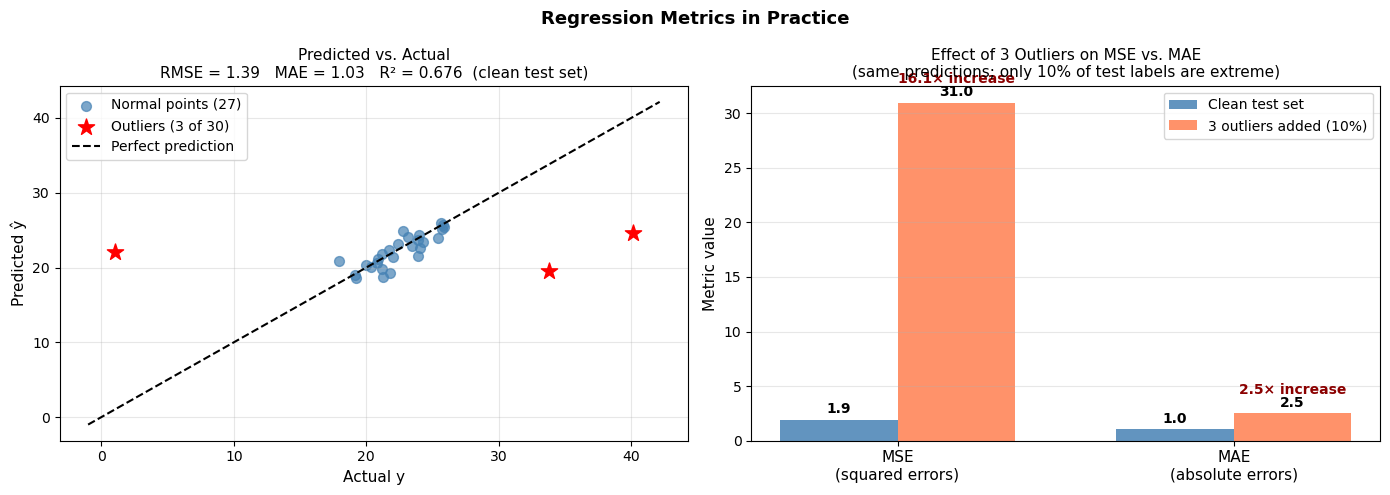

                                MSE       MAE      RMSE
Clean (30 test points)         1.93      1.03      1.39
With 3 outliers (10%)         30.97      2.54      5.57

MSE multiplied by 16.1×  |  MAE multiplied by 2.5×

A residual of ±18 contributes 324 to MSE but only 18 to MAE.
With 3 such outliers across 30 points, MSE is overwhelmed; MAE stays representative.


In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
n = 100

# Simple linear data with mild noise
X = np.linspace(0, 10, n).reshape(-1, 1)
y = 2.5 * X.ravel() + 1.0 + np.random.normal(0, 1.5, n)

# Deterministic split: train on first 70, test on last 30
X_train, X_test = X[:70], X[70:]
y_train, y_test = y[:70], y[70:]

model  = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# ── Clean metrics ───────────────────────────────────────────────────────────
mse_clean  = mean_squared_error(y_test, y_pred)
mae_clean  = mean_absolute_error(y_test, y_pred)
rmse_clean = np.sqrt(mse_clean)
r2         = r2_score(y_test, y_pred)

# ── Inject 3 large outliers directly into the test labels ───────────────────
# 3 of the 30 test points (10%) have extreme residuals
outlier_idx  = [4, 14, 24]
y_test_out   = y_test.copy()
y_test_out[outlier_idx[0]] += 18
y_test_out[outlier_idx[1]] -= 20
y_test_out[outlier_idx[2]] += 16

mse_out  = mean_squared_error(y_test_out, y_pred)
mae_out  = mean_absolute_error(y_test_out, y_pred)

# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predicted vs. actual — normal points in blue, outliers as red stars
ax   = axes[0]
mask = np.ones(len(y_test), dtype=bool)
mask[outlier_idx] = False

ax.scatter(y_test[mask],             y_pred[mask],          c='steelblue', alpha=0.7, s=50,
           label='Normal points (27)')
ax.scatter(y_test_out[outlier_idx],  y_pred[outlier_idx],   c='red', s=150,
           marker='*', zorder=5, label='Outliers (3 of 30)')
lims = [min(y_test_out.min(), y_pred.min()) - 2,
        max(y_test_out.max(), y_pred.max()) + 2]
ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual y',    fontsize=11)
ax.set_ylabel('Predicted ŷ', fontsize=11)
ax.set_title(f'Predicted vs. Actual\n'
             f'RMSE = {rmse_clean:.2f}   MAE = {mae_clean:.2f}   R² = {r2:.3f}  '
             f'(clean test set)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: grouped bar chart — MSE and MAE, clean vs. with outliers
ax    = axes[1]
x_pos = np.array([0, 1])
w     = 0.35
b1 = ax.bar(x_pos - w/2, [mse_clean, mae_clean], w,
            color='steelblue', alpha=0.85, label='Clean test set')
b2 = ax.bar(x_pos + w/2, [mse_out,   mae_out  ], w,
            color='coral',     alpha=0.85, label='3 outliers added (10%)')

for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Annotate the multiplier for each metric
for i, (clean_val, out_val) in enumerate([(mse_clean, mse_out),
                                           (mae_clean, mae_out)]):
    ratio = out_val / clean_val
    ax.annotate(f'{ratio:.1f}× increase',
                xy=(x_pos[i] + w/2, out_val + 1.5),
                ha='center', va='bottom',
                fontsize=10, color='darkred', fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(['MSE\n(squared errors)', 'MAE\n(absolute errors)'], fontsize=11)
ax.set_ylabel('Metric value', fontsize=11)
ax.set_title('Effect of 3 Outliers on MSE vs. MAE\n'
             '(same predictions; only 10% of test labels are extreme)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Regression Metrics in Practice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary ─────────────────────────────────────────────────────────────────
print(f'{"":25s}  {"MSE":>8s}  {"MAE":>8s}  {"RMSE":>8s}')
print(f'{"Clean (30 test points)":25s}  {mse_clean:8.2f}  {mae_clean:8.2f}  {rmse_clean:8.2f}')
print(f'{"With 3 outliers (10%)":25s}  {mse_out:8.2f}  {mae_out:8.2f}  {np.sqrt(mse_out):8.2f}')
print()
print(f'MSE multiplied by {mse_out/mse_clean:.1f}×  |  MAE multiplied by {mae_out/mae_clean:.1f}×')
print()
print('A residual of ±18 contributes 324 to MSE but only 18 to MAE.')
print('With 3 such outliers across 30 points, MSE is overwhelmed; MAE stays representative.')

### Choosing the Right Metric

With so many metrics available, a natural question is: *which one should I use?* The answer depends on your problem. Here is a quick decision guide:

| Situation | Recommended metric | Why |
|---|---|---|
| General-purpose reporting | **RMSE** | Same units as $y$; most widely used; penalizes large errors |
| Outlier-robust / noisy labels | **MAE** | Linear penalty; not dominated by extreme values |
| Explaining to non-ML audience | **R²** | Familiar; "proportion of variance explained" |

### Classification metrics

For classification problems, we need different metrics than the regression metrics above, because our target $y$ is a class label rather than a continuous number.

- **Accuracy** is probably the simplest and most common.  It just measures the number of values
predicted correctly divided by the total number of values.

Accuracy, however, can be misleading when the number of data points in each of our classes
is unbalanced.  Consider an example where we have 100 data points, but 95 of them are from the positive
class and only 5 are from the negative class.  Assume we have a machine learning model that always 
predicts the positive class ($f(x) = 1$), no matter what $x$ is.  The accuracy of this model
will be 95%, but obviously it will always miss predictions for the negative class, which probably isn't
very useful.

We have a few ways to make better metrics:

Let's assume our classification problem is trying to predict whether someone has a disease or not.  
We build a binary classifier for this and will predict either 1 (has the disease) or 0 (does not 
have the disease).  There are some standardized terms we can use:

- A **true positive** is predicting 1 (positive) when the patient actually has the disease.
- A **true negative** is predicting 0 (negative) when the patient does not have the disease.
- A **false positive** is predicting 1 when the patient does **not** have the disease.
- A **false negative** is predicting 0 when the patient **does** have the disease.

We will use TP, TN, FP, and FN as abbreviations for the total number of these occurrences in a data set.

### Confusion matrix:

```
                     Predicted +     Predicted -
                  +---------------+---------------+
  Actual +        |      TP       |      FN       |
                  +---------------+---------------+
  Actual -        |      FP       |      TN       |
                  +---------------+---------------+
```

Example: Suppose 100 people visit a doctor's office to be tested for a disease.  Only 20 of them
actually have the disease, but we don't know which 20 (or even that there are 20 who have it, so we
just test everybody).  We have a new state-of-the-art machine learning model that we've trained to detect
the disease.  Of the 20 people who have the disease, the ML model predicts positive for 15 of them.
Of the 80 who don't have the disease, the prediction comes back positive for 5 of them. 
The confusion matrix would look like this:

```
                     Predicted +     Predicted -
                  +---------------+---------------+
  Actual +        |      15       |       5       |
                  +---------------+---------------+
  Actual -        |       5       |      75       |
                  +---------------+---------------+
```

A few common metrics using these values are:

- **True positive rate (TPR)**: $\dfrac{TP}{TP+FN}$.  Also called sensitivity.

- **True negative rate (TNR)**: $\dfrac{TN}{TN+FP}$.  Also called specificity.

- **Balanced accuracy** = $\dfrac{TPR + TNR}{2}$.  Useful for imbalanced datasets because it weights both classes equally regardless of how many examples are in each class.

- **(regular) accuracy** = $\dfrac{TP+TN}{TP+FP+TN+FN}$

Sensitivity and specificity are often used in the medical world. 
In ML, we also often use:

- **Precision** = $\dfrac{TP}{TP+FP}$.

- **Recall** = $\dfrac{TP}{TP+FN}$.  Note this is the same thing as sensitivity = true positive rate.

- **F1 Score** = harmonic mean of precision and recall = $2\dfrac{Prec \cdot Recall}{Prec + Recall}$

**Important:** Recall and sensitivity are the *same quantity* ($\frac{TP}{TP+FN}$), just named differently depending on the field. The two "when to use" sections below give guidance for the same underlying number; the difference is context and framing, not math.

### When to Use Sensitivity/Specificity
Use when you care about actual condition detection (usually in medical, diagnostic, or screening settings):

- Sensitivity is vital if missing a positive case is dangerous (e.g., cancer detection).

- Specificity matters if you want to avoid false alarms (e.g., misdiagnosing healthy patients).

Example: Disease Screening

- Sensitivity tells you: Of all people who actually have the disease, how many did we correctly find?

- Specificity tells you: Of all people who are healthy, how many did we correctly ignore?

### When to Use Precision/Recall
Use when you care about how useful or trustworthy the model's positive predictions are, especially in imbalanced datasets.

- Precision is important when false positives are costly (e.g., spam filters, fraud alerts).

- Recall is crucial when missing a true positive is bad (e.g., catching all fraud cases).

 Example: Spam Filtering

- Precision: Of all emails marked spam, how many really were spam?

- Recall: Of all spam emails, how many did we catch?

### Classification Metrics in Practice

To understand *why* precision and recall matter separately from accuracy, consider a **disease detection** scenario: 1,000 patients, 100 of whom actually have the disease. We compare three classifiers with very different behavior:

| Classifier | Strategy |
|---|---|
| **Lazy** | Always predicts "healthy," so never flags anyone |
| **Aggressive Screener** | Catches 95 of 100 sick patients, but generates many false alarms |
| **Conservative Diagnoser** | Only flags very confident cases: precise but misses half the sick patients |

Look at the confusion matrices and the bar chart together. Pay close attention to what happens to **accuracy** for the lazy classifier and ask yourself whether that number is telling you anything useful.

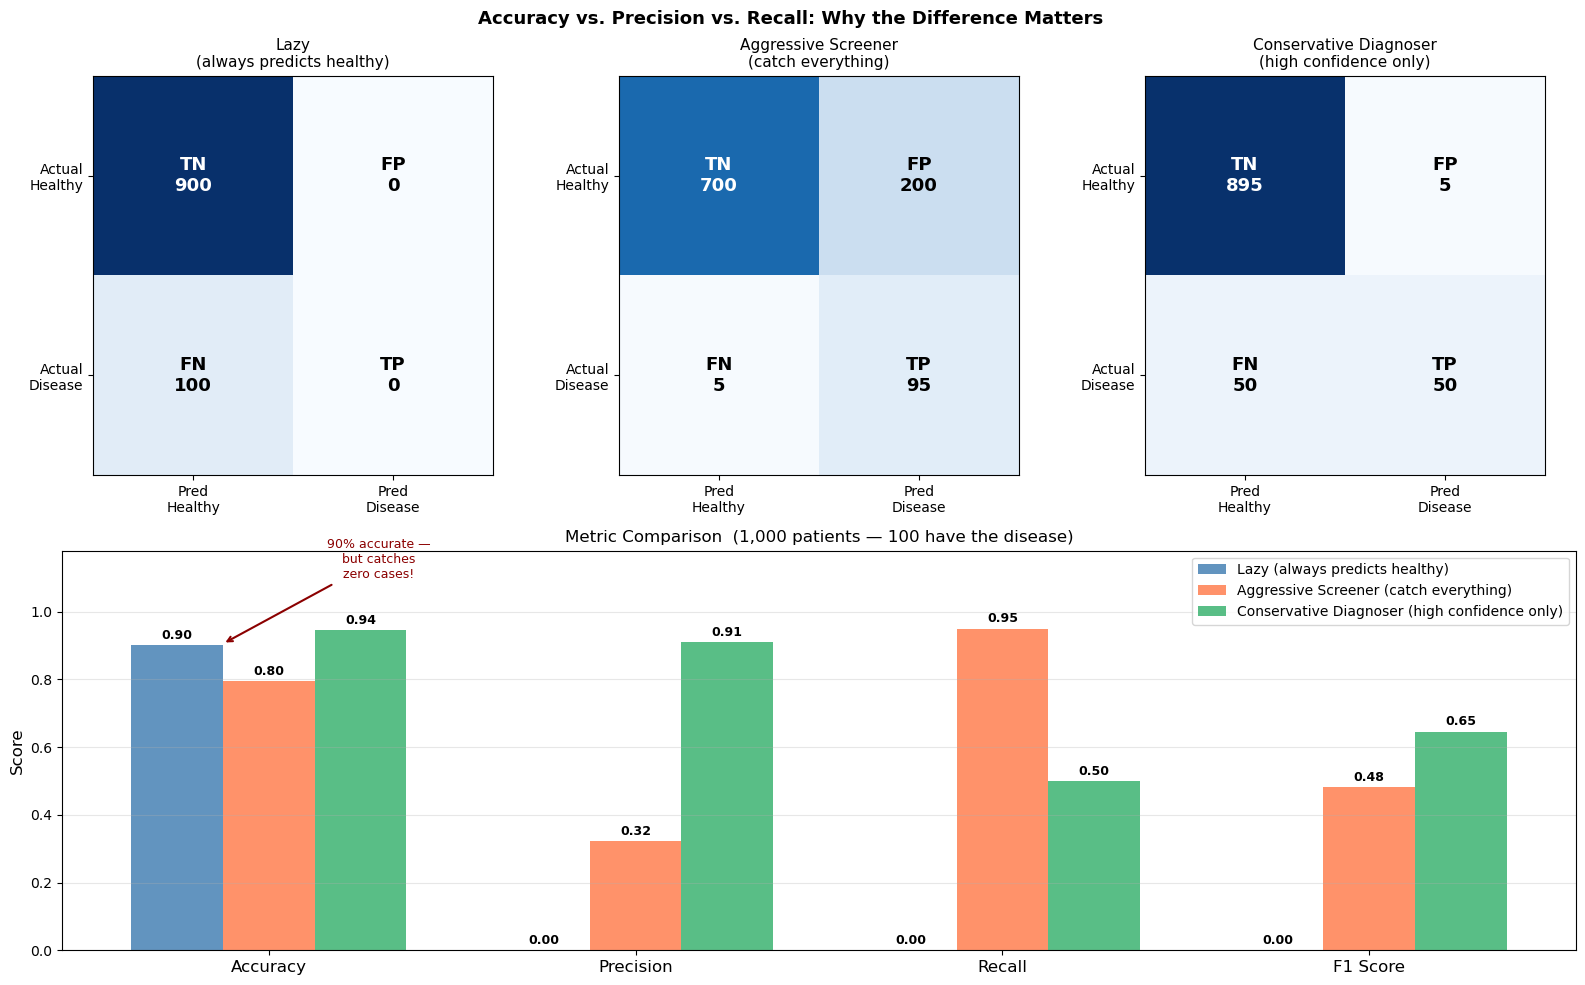

Classification report — Aggressive Screener:
              precision    recall  f1-score   support

 Healthy (0)       0.99      0.78      0.87       900
 Disease (1)       0.32      0.95      0.48       100

    accuracy                           0.80      1000
   macro avg       0.66      0.86      0.68      1000
weighted avg       0.93      0.80      0.83      1000



In [87]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)

# 1,000 patients: 900 healthy (0), 100 with disease (1)
y_true = np.array([0]*900 + [1]*100)

# Three classifiers with very different behavior:
y_pred_lazy  = np.array([0]*900 + [0]*100)           # always predicts healthy
y_pred_aggr  = np.array([0]*700 + [1]*200 + [0]*5  + [1]*95)  # catches most, many false alarms
y_pred_cons  = np.array([0]*895 + [1]*5   + [0]*50 + [1]*50)  # high confidence only

scenarios = [
    ('Lazy\n(always predicts healthy)',          y_pred_lazy, 'steelblue'),
    ('Aggressive Screener\n(catch everything)',   y_pred_aggr, 'coral'),
    ('Conservative Diagnoser\n(high confidence only)', y_pred_cons, 'mediumseagreen'),
]

def get_metrics(y_true, y_pred):
    return [accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, zero_division=0),
            recall_score(y_true, y_pred),
            f1_score(y_true, y_pred, zero_division=0)]

fig = plt.figure(figsize=(16, 10))

# ── Top row: one confusion matrix per classifier ──────────────────
for i, (name, y_pred, color) in enumerate(scenarios):
    ax  = fig.add_subplot(2, 3, i + 1)
    cm  = confusion_matrix(y_true, y_pred)
    im  = ax.imshow(cm, cmap='Blues', vmin=0, vmax=900)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred\nHealthy', 'Pred\nDisease'], fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual\nHealthy', 'Actual\nDisease'], fontsize=10)
    cell_names = {(0,0): 'TN', (0,1): 'FP', (1,0): 'FN', (1,1): 'TP'}
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cell_names[(r,c)]}\n{cm[r,c]}',
                    ha='center', va='center', fontsize=13, fontweight='bold',
                    color='white' if cm[r,c] > 450 else 'black')
    ax.set_title(name, fontsize=11)

# ── Bottom row: grouped bar chart comparing all four metrics ──────
ax_bar = fig.add_subplot(2, 1, 2)
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x     = np.arange(len(metric_names))
width = 0.25

for i, (name, y_pred, color) in enumerate(scenarios):
    vals = get_metrics(y_true, y_pred)
    bars = ax_bar.bar(x + i * width, vals, width,
                      label=name.replace('\n', ' '), color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(metric_names, fontsize=12)
ax_bar.set_ylim(0, 1.18)
ax_bar.set_ylabel('Score', fontsize=12)
ax_bar.set_title('Metric Comparison  (1,000 patients — 100 have the disease)', fontsize=12)
ax_bar.legend(fontsize=10)
ax_bar.grid(True, alpha=0.3, axis='y')

# Annotate the deceptively high lazy accuracy
ax_bar.annotate('90% accurate —\nbut catches\nzero cases!',
                xy=(x[0] + 0 * width + width / 2, 0.905),
                xytext=(x[0] + 0.55, 1.10),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
                fontsize=9, color='darkred', ha='center')

plt.suptitle('Accuracy vs. Precision vs. Recall: Why the Difference Matters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# classification_report() — the standard tool you will use in practice
print("Classification report — Aggressive Screener:")
print(classification_report(y_true, y_pred_aggr, target_names=['Healthy (0)', 'Disease (1)']))

### Multi-Class Metrics: Macro and Weighted Averaging

Everything above assumes **binary** classification (positive vs. negative). The moment you have three or more classes, a natural question arises: how do you summarize precision, recall, and F1 across all of them in a single number?

**Step 1: per-class metrics.**
For each class, sklearn treats it as a one-vs-rest binary problem: "Is this example class *k*, or not?" That gives an independent precision, recall, and F1 for every class. You can see these in the rows of `classification_report`.

Per-class precision for class $k$ = $\dfrac{TP_k}{TP_k + FP_k}$ where $TP_k$ = instances of class $k$ that were correctly predicted as $k$, and 
$FP_k$ = instances of other classes that were incorrectly predicted as $k$.

Interpretation: "Of everything the model predicted as $k$, how much actually was $k$?"

Per-class recall for class $k$ = $\dfrac{TP_k}{TP_k + FN_k}$ where 
$FN_k$ = instances of class $k$ that were incorrectly predicted as some other class.

Interpretation: "Of everything that actually was $k$, how much did the model predict as $k$?"

**Step 2: summarize across classes.**
The bottom of `classification_report` shows two averaging strategies (plus plain accuracy):

| Average | How it's computed | Use it when... |
|---------|-------------------|--------------|
| **Macro** | Unweighted mean of per-class scores | You care equally about all classes, even rare ones |
| **Weighted** | Mean weighted by each class's **support** (# true instances) | Classes are imbalanced; larger classes should matter more |


**Why does it matter?**
With imbalanced classes, macro and weighted averages can tell very different stories. A model that completely ignores a rare minority class can still achieve a high *weighted* F1, because the minority class contributes little weight. *Macro* average punishes that failure equally, regardless of class size.

> **Practical rule of thumb:** Report *weighted* F1 when your test set reflects real-world class frequencies and larger classes deserve more weight. Report *macro* F1 when all classes are equally important (e.g., a diagnostic system where missing any disease is equally bad).

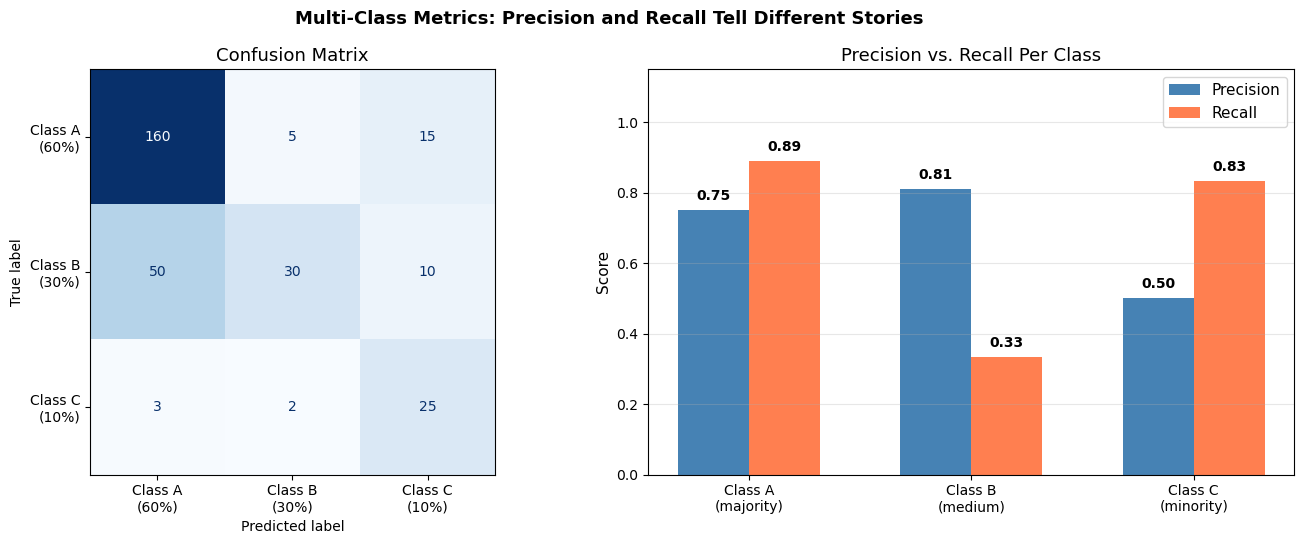

classification_report() output
               precision    recall  f1-score   support

Class A (60%)       0.75      0.89      0.81       180
Class B (30%)       0.81      0.33      0.47        90
Class C (10%)       0.50      0.83      0.62        30

     accuracy                           0.72       300
    macro avg       0.69      0.69      0.64       300
 weighted avg       0.74      0.72      0.69       300

Per-class stories:
  Class B — Precision 0.81, Recall 0.33
            Conservative: when it predicts B it's usually right,
            but it misses 2/3 of actual B's (labels them A instead).

  Class C — Precision 0.50, Recall 0.83
            Aggressive: it catches most real C's, but half
            of its C predictions are actually A's or B's.

Averaging strategies:
  Macro    avg F1 = 0.637  ← pulled down by class B's poor recall
  Weighted avg F1 = 0.693  ← dominated by class A (60% of data)


In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay,
                             precision_recall_fscore_support, f1_score)

# ── Hand-crafted predictions for a 3-class imbalanced problem ───────────────
# 300 test examples: 60% class A, 30% class B, 10% class C
#
# Each class tells a different precision/recall story:
#   Class A (majority): model does reasonably well on both
#   Class B (medium):   model is CONSERVATIVE — rarely predicts B,
#                       so precision is high but recall is very low
#   Class C (minority): model is AGGRESSIVE — catches most C's,
#                       but flags many non-C's as C too (low precision)

y_true = np.array([0]*180 + [1]*90 + [2]*30)

y_pred = np.array(
    # 180 true A → 160 pred A, 5 pred B, 15 pred C
    [0]*160 + [1]*5  + [2]*15 +
    # 90 true B  → 50 pred A, 30 pred B, 10 pred C
    [0]*50  + [1]*30 + [2]*10 +
    # 30 true C  → 3 pred A, 2 pred B, 25 pred C
    [0]*3   + [1]*2  + [2]*25
)

# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: confusion matrix
class_labels = ['Class A\n(60%)', 'Class B\n(30%)', 'Class C\n(10%)']
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# Right: precision vs recall per class (grouped bars)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])

x = np.arange(3)
w = 0.32
b1 = axes[1].bar(x - w/2, prec, w, color='steelblue', label='Precision')
b2 = axes[1].bar(x + w/2, rec,  w, color='coral',      label='Recall')

for bars in [b1, b2]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{bar.get_height():.2f}', ha='center', va='bottom',
                     fontsize=10, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(['Class A\n(majority)', 'Class B\n(medium)', 'Class C\n(minority)'],
                         fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Precision vs. Recall Per Class', fontsize=13)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Multi-Class Metrics: Precision and Recall Tell Different Stories',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── classification_report ───────────────────────────────────────────────────
print("=" * 62)
print("classification_report() output")
print("=" * 62)
print(classification_report(y_true, y_pred,
                             target_names=['Class A (60%)',
                                           'Class B (30%)',
                                           'Class C (10%)']))

f1_macro    = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("Per-class stories:")
print(f"  Class B — Precision {prec[1]:.2f}, Recall {rec[1]:.2f}")
print(f"            Conservative: when it predicts B it's usually right,")
print(f"            but it misses 2/3 of actual B's (labels them A instead).")
print()
print(f"  Class C — Precision {prec[2]:.2f}, Recall {rec[2]:.2f}")
print(f"            Aggressive: it catches most real C's, but half")
print(f"            of its C predictions are actually A's or B's.")
print()
print(f"Averaging strategies:")
print(f"  Macro    avg F1 = {f1_macro:.3f}  ← pulled down by class B's poor recall")
print(f"  Weighted avg F1 = {f1_weighted:.3f}  ← dominated by class A (60% of data)")

## Recommended metrics for classification:



| Situation | Recommended metric | Why |
|---|---|---|
| Balanced classes, simple summary | **Accuracy** | Easy to understand; reliable when classes are balanced |
| Imbalanced classes, simple summary | **Balanced accuracy** or **F1** | Accuracy is misleading when one class dominates |
| False positives are costly (spam, fraud alerts) | **Precision** | "Of everything the model identified, how much was real?" |
| False negatives are costly (disease, safety) | **Recall** (= sensitivity) | "Of everything that was real, how much did the model identify?" |
| Multi-class, all classes equally important | **Macro F1** | Treats every class the same regardless of size |
| Multi-class, larger classes matter more | **Weighted F1** | Weights by class frequency |

> **In practice, report more than one metric.** A single number can always hide something. At minimum, report accuracy *and* F1 for classification. If classes are imbalanced, always include per-class precision, recall, and the confusion matrix.

## What if I don't have enough data?

While large data sets are now common in machine learning, we don't always have enough data to split
the data set into a large enough subset to train on, plus a large enough set to test on as well.  Or,
even if we do have enough data, we know that training a model on **more** data almost always results in a
better model, so it seems silly to let 1/3 or 20% of our data "go to waste" and not use it for training.

A common solution to this is called **cross-validation**, and there are a few ways to do it:

- **$k$-fold cross-validation**: This is a nice method if you have a pretty big data set but you don't feel like you can hold back 1/3 or 20% of it for testing.

  We will partition the entire data set into $k$ equally-sized subsets.  Of the $k$ subsets, we choose one of them to be the testing set, and the other $k-1$ subsets combined will form the training set.  We train our model on the training set and test it on the testing set as normal.  Then, we repeat this process but **using a different subset of the original $k$ subsets for the testing set**.  We will usually then average all the evaluations from each of the $k$ individual training/testing cycles.

  Example: In 10-fold cross-validation (common), we divide our entire set into 10 roughly equal-sized subsets.
  Then, we cycle through the training/testing process while keeping one of the subsets as our testing set and nine
  of them (combined) as our training set.
  
  (Note: typically we must make sure to do this partitioning of the original data in such a way that the output labels/predictions in each subset match the overall distribution of the labels/predictions).
  
- **Leave $p$ out cross-validation**: This is even more extreme than $k$-fold cross-validation, but
is nice when your data set is very small.  

  In this method, we remove $p$ data points from the data set and use only those $p$ points for testing. The rest of the data is used for training.  We repeat this process with every possible set of $p$ data points from the original data, and average all of the evaluations on the different testing sets.
  
  This method quickly becomes unwieldy for large values of $p$, but it is very commonly used with $p=1$, or **leave-one-out cross-validation (LOOCV)**.  Here, we cycle through our entire data set and use each individual data point in turn as the sole member of the testing set, training on all the rest of the data except that one point.  We average all the results.
  
<hr>

<b>The key idea in all of these methods is that we never use the same data point in both the testing and training sets.</b>